# Section 6 Analysis — v2 paper figures and tables

One cell per figure. Outputs saved as PNG/CSV next to the notebook.

**Inputs needed in the same directory:**
- `batch_results_v2.csv`
- `backfire_causal_results_v2.csv`
- `cf_density_results.csv`
- `trajectory_results_v3.csv`

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
})

# Baseline drawn first as a dark reference line; other regimes layered on top.
REGIME_ORDER = ['individual_baseline', 'local_cf', 'global_trending', 'hybrid']
REGIME_COLORS = {
    'individual_baseline': '#4a4a4a',   # dark grey reference
    'local_cf':            '#2ca02c',
    'global_trending':     '#d62728',
    'hybrid':              '#1f77b4',
}
REGIME_LSTYLE = {
    'individual_baseline': '--',        # dashed reference
    'local_cf':            '-',
    'global_trending':     '-',
    'hybrid':              '-',
}
REGIME_LABELS = {
    'individual_baseline': 'Individual baseline',
    'local_cf':            'Local CF',
    'global_trending':     'Global trending',
    'hybrid':              'Hybrid',
}
DIST_ORDER = ['polarized', 'uniform', 'moderate']
DIST_TITLES = {
    'polarized': 'Initial: polarized',
    'uniform':   'Initial: uniform',
    'moderate':  'Initial: moderate',
}

## Figure 1 — Regime × width × distribution (headline figure)

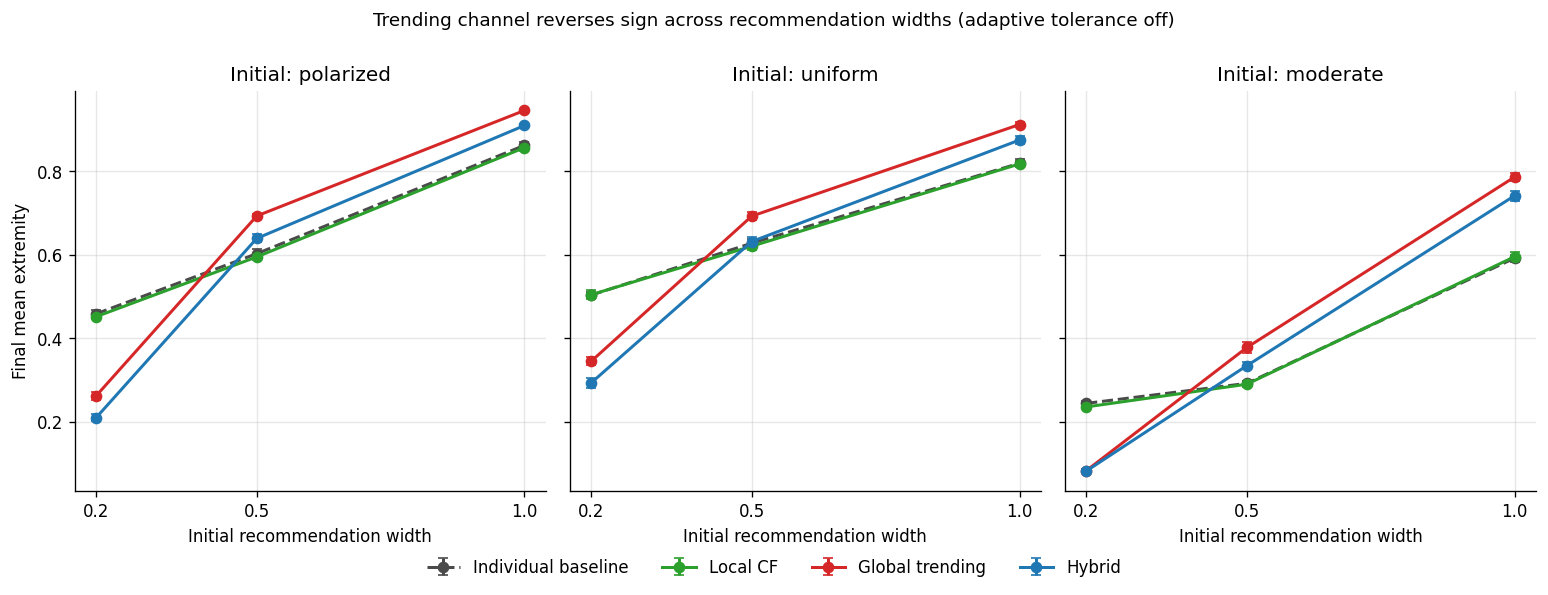

In [3]:
df = pd.read_csv('batch_results_v2.csv')
sub = df[df['adaptive_tolerance'] == False]

agg = (sub.groupby(['initial_distribution',
                    'initial_preference_width',
                    'regime'])['final_mean_extremity']
         .agg(['mean', 'std', 'count']).reset_index())
agg['se'] = agg['std'] / np.sqrt(agg['count'])

fig, axes = plt.subplots(1, 3, figsize=(13, 4.6), sharey=True)

for ax, dist in zip(axes, DIST_ORDER):
    d = agg[agg['initial_distribution'] == dist]
    for regime in REGIME_ORDER:
        dd = d[d['regime'] == regime].sort_values('initial_preference_width')
        ax.errorbar(
            dd['initial_preference_width'], dd['mean'],
            yerr=1.96 * dd['se'],
            marker='o', label=REGIME_LABELS[regime],
            color=REGIME_COLORS[regime],
            linestyle=REGIME_LSTYLE[regime],
            linewidth=1.8, capsize=3, markersize=6,
        )
    ax.set_title(DIST_TITLES[dist])
    ax.set_xlabel('Initial recommendation width')
    ax.set_xticks([0.20, 0.50, 1.00])
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Final mean extremity')

# Single legend below the row of axes — no overlap with data.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='lower center', bbox_to_anchor=(0.5, -0.05),
           ncol=4, frameon=False, fontsize=10)

fig.suptitle('Trending channel reverses sign across recommendation widths '
             '(adaptive tolerance off)',
             fontsize=11, y=1.00)
plt.tight_layout()
plt.savefig('fig1_regime_width_distribution.png',
            bbox_inches='tight', dpi=150)
plt.show()

## Figure 2 — CF density sweep (specificity evidence)

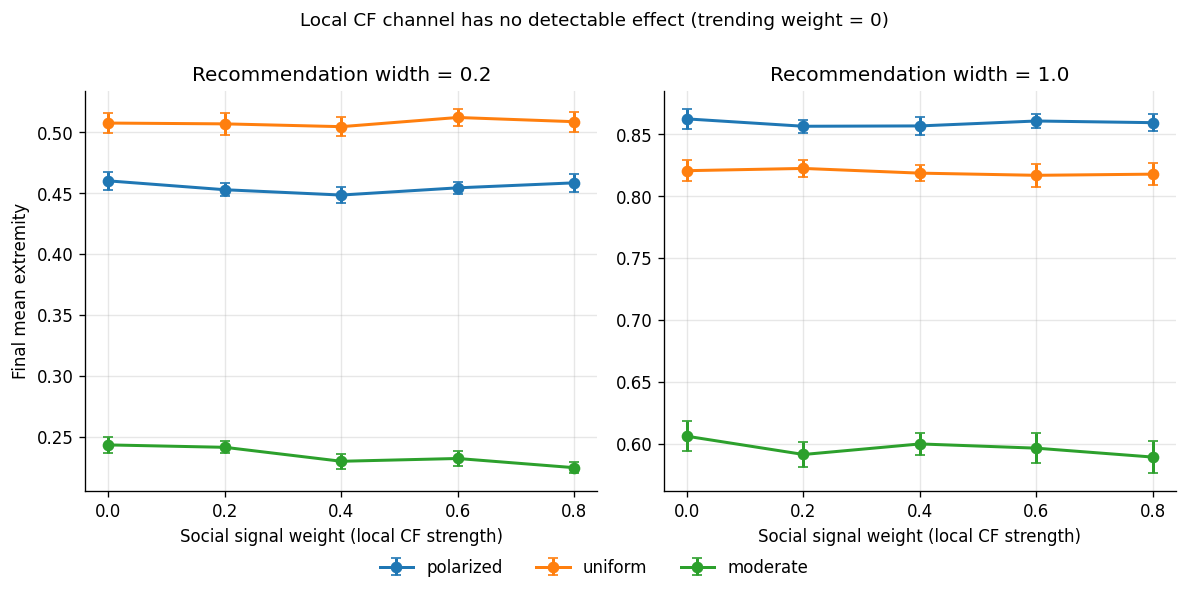

In [4]:
df = pd.read_csv('cf_density_results.csv')

agg = (df.groupby(['initial_distribution', 'initial_preference_width',
                   'social_signal_weight'])['final_mean_extremity']
         .agg(['mean', 'std', 'count']).reset_index())
agg['se'] = agg['std'] / np.sqrt(agg['count'])

DIST_COLORS = {'polarized': '#1f77b4',
               'uniform':   '#ff7f0e',
               'moderate':  '#2ca02c'}

fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), sharey=False)

for ax, w in zip(axes, [0.20, 1.00]):
    d = agg[agg['initial_preference_width'] == w]
    for dist in DIST_ORDER:
        dd = d[d['initial_distribution'] == dist].sort_values('social_signal_weight')
        ax.errorbar(
            dd['social_signal_weight'], dd['mean'],
            yerr=1.96 * dd['se'],
            marker='o', label=dist, color=DIST_COLORS[dist],
            linewidth=1.8, capsize=3, markersize=6,
        )
    ax.set_title(f'Recommendation width = {w}')
    ax.set_xlabel('Social signal weight (local CF strength)')
    ax.set_ylabel('Final mean extremity' if w == 0.20 else '')
    ax.grid(alpha=0.3)
    ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='lower center', bbox_to_anchor=(0.5, -0.05),
           ncol=3, frameon=False, fontsize=10)

fig.suptitle('Local CF channel has no detectable effect (trending weight = 0)',
             fontsize=11, y=1.00)
plt.tight_layout()
plt.savefig('fig2_cf_density.png', bbox_inches='tight', dpi=150)
plt.show()

## Figure 3 — Backfire ablation × regime × width

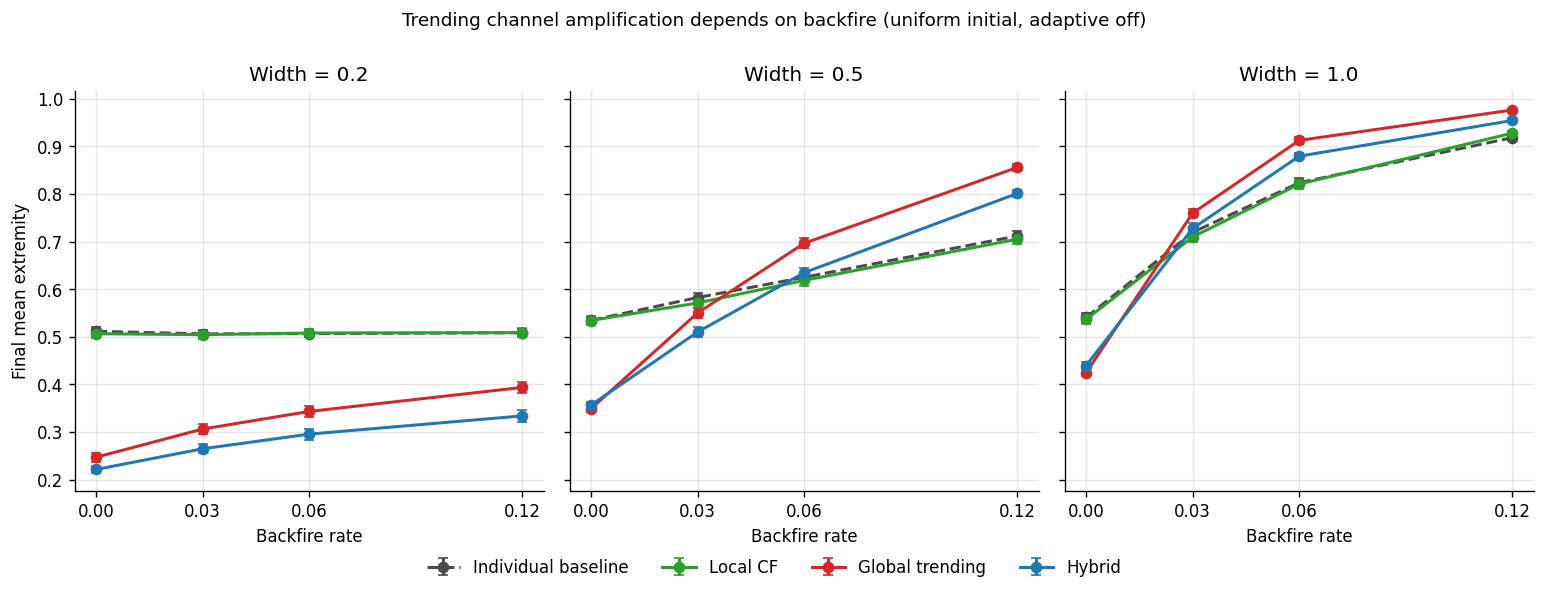

In [5]:
df = pd.read_csv('backfire_causal_results_v2.csv')

agg = (df.groupby(['regime', 'initial_preference_width',
                   'backfire_rate'])['final_mean_extremity']
         .agg(['mean', 'std', 'count']).reset_index())
agg['se'] = agg['std'] / np.sqrt(agg['count'])

fig, axes = plt.subplots(1, 3, figsize=(13, 4.6), sharey=True)

for ax, w in zip(axes, [0.20, 0.50, 1.00]):
    d = agg[agg['initial_preference_width'] == w]
    for regime in REGIME_ORDER:
        dd = d[d['regime'] == regime].sort_values('backfire_rate')
        ax.errorbar(
            dd['backfire_rate'], dd['mean'],
            yerr=1.96 * dd['se'],
            marker='o', label=REGIME_LABELS[regime],
            color=REGIME_COLORS[regime],
            linestyle=REGIME_LSTYLE[regime],
            linewidth=1.8, capsize=3, markersize=6,
        )
    ax.set_title(f'Width = {w}')
    ax.set_xlabel('Backfire rate')
    ax.grid(alpha=0.3)
    ax.set_xticks([0.00, 0.03, 0.06, 0.12])

axes[0].set_ylabel('Final mean extremity')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='lower center', bbox_to_anchor=(0.5, -0.05),
           ncol=4, frameon=False, fontsize=10)

fig.suptitle('Trending channel amplification depends on backfire '
             '(uniform initial, adaptive off)',
             fontsize=11, y=1.00)
plt.tight_layout()
plt.savefig('fig3_backfire_ablation.png', bbox_inches='tight', dpi=150)
plt.show()

## Figure 4 — Trajectory shapes (2 × 3 grid: width × distribution)

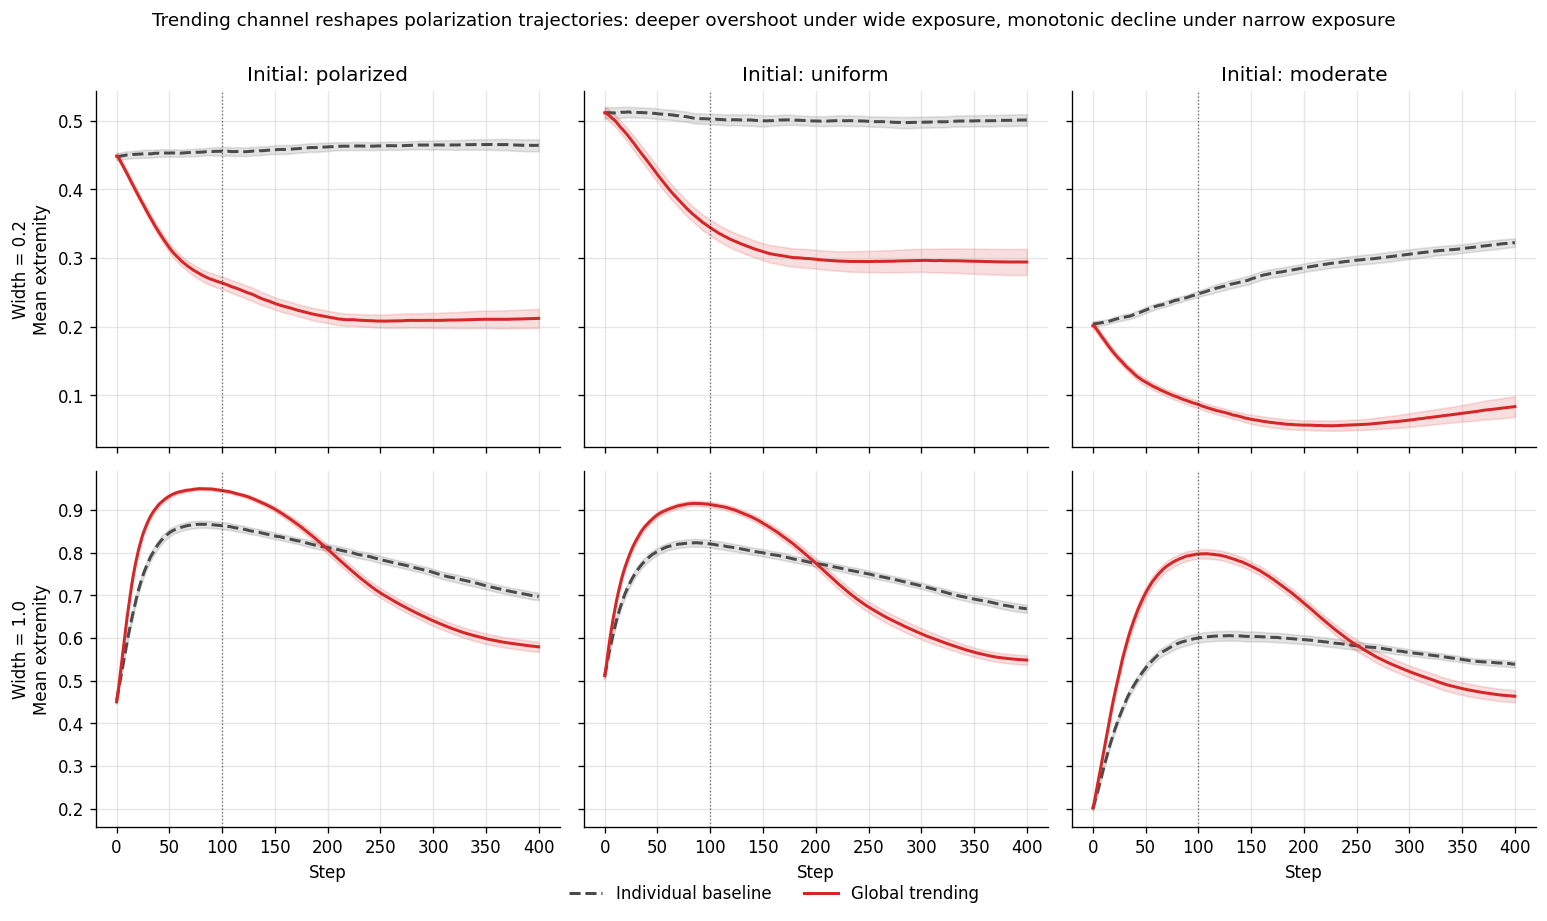

In [6]:
df = pd.read_csv('trajectory_results_v3.csv')

fig, axes = plt.subplots(2, 3, figsize=(13, 7.4), sharey='row', sharex=True)

for row, w in enumerate([0.20, 1.00]):
    for col, dist in enumerate(DIST_ORDER):
        ax = axes[row, col]
        # Baseline drawn first (dashed dark grey reference)
        for regime in ['individual_baseline', 'global_trending']:
            sub = df[(df['regime'] == regime) &
                     (df['initial_distribution'] == dist) &
                     (df['initial_preference_width'] == w)]
            grouped = sub.groupby('step')['Mean Extremity'].agg(
                ['mean', 'std', 'count']).reset_index()
            grouped['se'] = grouped['std'] / np.sqrt(grouped['count'])
            ax.plot(
                grouped['step'], grouped['mean'],
                label=REGIME_LABELS[regime],
                color=REGIME_COLORS[regime],
                linestyle=REGIME_LSTYLE[regime],
                linewidth=1.8,
            )
            ax.fill_between(
                grouped['step'],
                grouped['mean'] - 1.96 * grouped['se'],
                grouped['mean'] + 1.96 * grouped['se'],
                color=REGIME_COLORS[regime], alpha=0.15,
            )
        ax.axvline(100, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
        if row == 0:
            ax.set_title(DIST_TITLES[dist])
        if col == 0:
            ax.set_ylabel(f'Width = {w}\nMean extremity')
        if row == 1:
            ax.set_xlabel('Step')
        ax.grid(alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='lower center', bbox_to_anchor=(0.5, -0.02),
           ncol=2, frameon=False, fontsize=10)

fig.suptitle('Trending channel reshapes polarization trajectories: '
             'deeper overshoot under wide exposure, '
             'monotonic decline under narrow exposure',
             fontsize=11, y=1.00)
plt.tight_layout()
plt.savefig('fig4_trajectory_shapes.png', bbox_inches='tight', dpi=150)
plt.show()

## Table A — Adaptive tolerance buffer effect by regime × width × distribution

In [7]:
df = pd.read_csv('batch_results_v2.csv')

# Compute mean final extremity by (distribution, width, regime, adaptive)
agg = df.groupby(
    ['initial_distribution', 'initial_preference_width',
     'regime', 'adaptive_tolerance']
)['final_mean_extremity'].mean().reset_index()

# Compute buffer effect = OFF - ON for each (distribution, width, regime)
off = agg[agg['adaptive_tolerance'] == False].set_index(
    ['initial_distribution', 'initial_preference_width', 'regime']
)['final_mean_extremity']
on = agg[agg['adaptive_tolerance'] == True].set_index(
    ['initial_distribution', 'initial_preference_width', 'regime']
)['final_mean_extremity']
buffer = (off - on).round(3).rename('buffer_effect').reset_index()

# Pivot to wide format: regime becomes columns, (distribution, width) become rows
table_a = buffer.pivot_table(
    index=['initial_distribution', 'initial_preference_width'],
    columns='regime',
    values='buffer_effect',
).reset_index()

# Reorder regime columns and rename for clarity
table_a = table_a[['initial_distribution', 'initial_preference_width',
                   'individual_baseline', 'local_cf',
                   'global_trending', 'hybrid']]
table_a.columns = ['Distribution', 'Width',
                   'Baseline', 'Local CF', 'Trending', 'Hybrid']

# Order rows: polarized, uniform, moderate; narrow -> wide
dist_order = {'polarized': 0, 'uniform': 1, 'moderate': 2}
table_a['_o'] = table_a['Distribution'].map(dist_order)
table_a = table_a.sort_values(['_o', 'Width']).drop(columns='_o').reset_index(drop=True)

# Format values with explicit + sign for buffer (positive = buffer, negative = amplify)
def fmt(v):
    if pd.isna(v):
        return ''
    return f'{v:+.3f}'

for col in ['Baseline', 'Local CF', 'Trending', 'Hybrid']:
    table_a[col] = table_a[col].apply(fmt)

table_a.to_csv('table_a_adaptive_buffer.csv', index=False)
table_a

,Distribution,Width,Baseline,Local CF,Trending,Hybrid
0,polarized,0.2,-0.003,-0.002,+0.086,+0.088
1,polarized,0.5,+0.043,+0.046,+0.122,+0.139
2,polarized,1.0,+0.077,+0.081,+0.003,+0.024
3,uniform,0.2,+0.010,+0.015,+0.066,+0.054
4,uniform,0.5,+0.077,+0.073,+0.099,+0.131
5,uniform,1.0,+0.077,+0.073,+0.003,+0.025
6,moderate,0.2,-0.062,-0.028,+0.024,+0.024
7,moderate,0.5,-0.020,-0.015,+0.095,+0.083
8,moderate,1.0,+0.039,+0.024,-0.014,-0.014


## Table B — Trajectory diagnostics

In [8]:
df = pd.read_csv('trajectory_results_v3.csv')

rows = []
for regime in df['regime'].unique():
    for dist in DIST_ORDER:
        for w in [0.20, 1.00]:
            sub = df[(df['regime'] == regime) &
                     (df['initial_distribution'] == dist) &
                     (df['initial_preference_width'] == w)]
            if len(sub) == 0:
                continue
            avg = sub.groupby('step')['Mean Extremity'].mean()
            peak_step = int(avg.idxmax())
            peak_val = float(avg.max())
            end_val = float(avg.iloc[-1])
            relaxation = peak_val - end_val
            quarter = int(400 * 0.75)
            mid_val = float(avg.iloc[quarter])
            slope = (end_val - mid_val) / (400 - quarter) * 100
            rows.append({
                'regime': regime, 'distribution': dist, 'width': w,
                'peak_step': peak_step,
                'peak_value': round(peak_val, 3),
                'end_value': round(end_val, 3),
                'relaxation': round(relaxation, 3),
                'late_slope_per_100': round(slope, 3),
            })
tb = pd.DataFrame(rows)
tb.to_csv('table_b_trajectory_diagnostics.csv', index=False)
tb

,regime,distribution,width,peak_step,peak_value,end_value,relaxation,late_slope_per_100
0,individual_baseline,polarized,0.2,342,0.465,0.464,0.001,-0.000
1,individual_baseline,polarized,1.0,79,0.866,0.697,0.169,-0.056
2,individual_baseline,uniform,0.2,22,0.512,0.501,0.012,0.003
3,individual_baseline,uniform,1.0,87,0.823,0.668,0.155,-0.054
4,individual_baseline,moderate,0.2,400,0.322,0.322,0.000,0.017
5,individual_baseline,moderate,1.0,129,0.605,0.538,0.067,-0.028
6,global_trending,polarized,0.2,0,0.448,0.212,0.236,0.003
7,global_trending,polarized,1.0,78,0.950,0.579,0.371,-0.061
8,global_trending,uniform,0.2,1,0.511,0.294,0.217,-0.002
9,global_trending,uniform,1.0,85,0.915,0.548,0.367,-0.062
